In [163]:
from IPython.display import display, Markdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder, OrdinalEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from ydata_profiling import ProfileReport
import warnings
import pickle
warnings.filterwarnings("ignore")
%matplotlib inline



In [164]:
train = pd.read_csv('D:/Projects/ML-Projects/WineQualityE2E/Data/Titanic_train.csv')
test = pd.read_csv('D:/Projects/ML-Projects/WineQualityE2E/Data/Titanic_test.csv')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Summarize dataset:  66%|██████▌   | 29/44 [00:08<00:04,  3.30it/s, scatter Fare, SibSp]             


KeyboardInterrupt: 

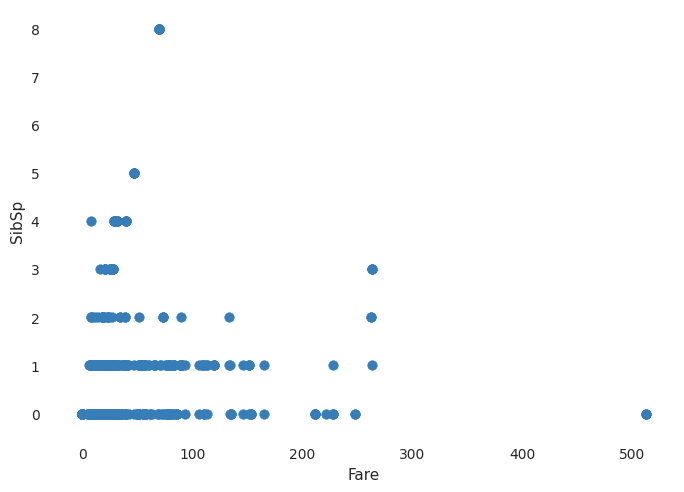

In [277]:
ProfileReport(train).to_file('D:/Projects/ML-Projects/WineQualityE2E/reports/Titanic.html')

In [ ]:
train.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
869,870,1,3,"Johnson, Master. Harold Theodor",male,4.0,1,1,347742,11.1333,NaN,S
357,358,0,2,"Funk, Miss. Annie Clemmer",female,38.0,0,0,237671,13.0000,NaN,S
240,241,0,3,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C
677,678,1,3,"Turja, Miss. Anna Sofia",female,18.0,0,0,4138,9.8417,NaN,S
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,76.7292,D33,C
145,146,0,2,"Nicholls, Mr. Joseph Charles",male,19.0,1,1,C.A. 33112,36.7500,NaN,S
144,145,0,2,"Andrew, Mr. Edgardo Samuel",male,18.0,0,0,231945,11.5000,NaN,S
502,503,0,3,"O'Sullivan, Miss. Bridget Mary",female,NaN,0,0,330909,7.6292,NaN,Q
114,115,0,3,"Attalah, Miss. Malake",female,17.0,0,0,2627,14.4583,NaN,C


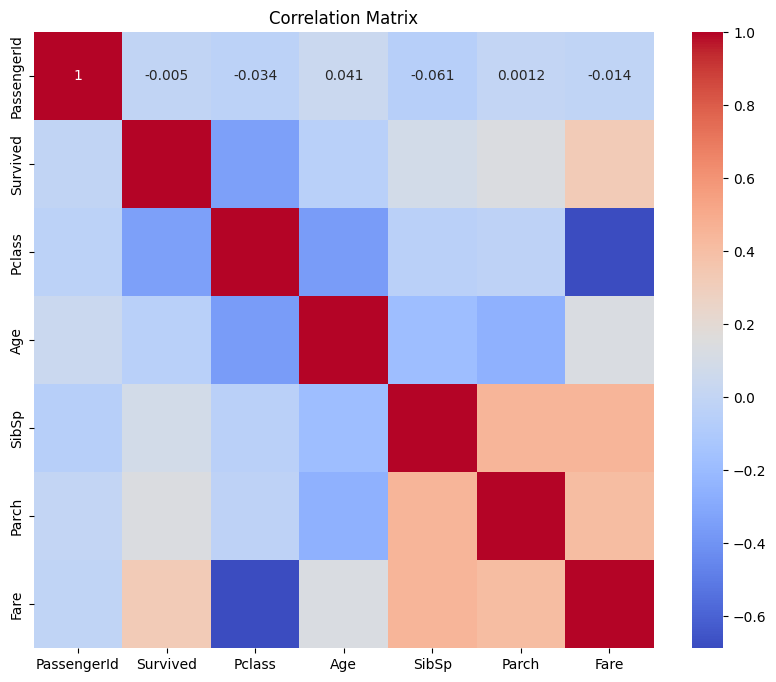

In [ ]:
corr = train.select_dtypes(include=['number']).corr(method = 'spearman')
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [165]:
train[train['Embarked'].isna()]
train = train.dropna(subset=['Embarked'])
train.shape

(889, 12)

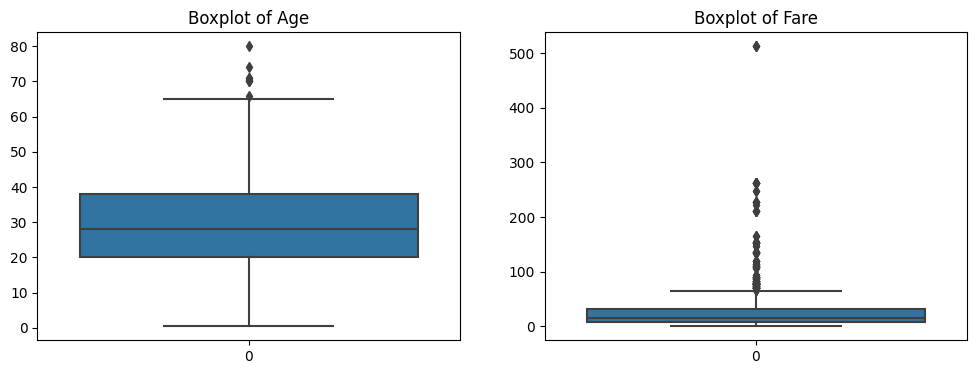

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.boxplot(train['Age'])
plt.title('Boxplot of Age')
plt.subplot(1,2,2)
sns.boxplot(train['Fare'])
plt.title('Boxplot of Fare')
plt.show()

In [166]:
train = train.drop(columns=['Name', 'Ticket', 'Cabin'])
test = test.drop(columns=['Name', 'Ticket', 'Cabin'])

In [167]:
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
def family_size_category(size):
    if size == 1:
        return 'Alone'
    elif 2 <= size <= 4:
        return 'Small'
    elif 5 <= size <= 6:
        return 'Medium'
    else:
        return 'Large'
train['FamilySizeCategory'] = train['FamilySize'].apply(family_size_category)
train['IsAlone'] = (train['FamilySize'] == 1).astype(int)

In [168]:
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1
def family_size_category(size):
    if size == 1:
        return 'Alone'
    elif 2 <= size <= 4:
        return 'Small'
    elif 5 <= size <= 6:
        return 'Medium'
    else:
        return 'Large'
test['FamilySizeCategory'] = test['FamilySize'].apply(family_size_category)
test['IsAlone'] = (test['FamilySize'] == 1).astype(int)

In [169]:
train = train.drop(columns=['SibSp', 'Parch', 'FamilySize'])
test = test.drop(columns=['SibSp', 'Parch', 'FamilySize'])

In [170]:
X_train, X_test, y_train, y_test = train_test_split(train.drop('Survived', axis=1), train['Survived'], test_size=0.2, random_state=42)

In [171]:
Nominal_features = ['Sex', 'Embarked']
Ordinal_features = ['Pclass']

In [172]:
Imputer = IterativeImputer(estimator = LinearRegression(), max_iter = 10, initial_strategy = 'mean')
PowerTransform = PowerTransformer(method='yeo-johnson')
NominalEncoding = OneHotEncoder(drop='first', sparse_output=False)
OrdinalEncoding = OrdinalEncoder()

In [173]:
preprocessor = ColumnTransformer(
    transformers=[
        ("Applying Transformation on Age Column",
         Pipeline(steps=[
            ("Imputing", Imputer),
            ("Transforming", PowerTransform),
            ("Scaling", StandardScaler())]),
            ['Age']),

        ("Applying Transformation on Fare Column",
         Pipeline(steps=[
            ("Imputing", Imputer),
            ("Transforming", PowerTransform),
            ("Scaling", StandardScaler())]), 
            ['Fare']),

        ("Encoding Nominal Categorical Features",
         Pipeline(steps=[
             ("NominalEncoding", NominalEncoding)]),
            Nominal_features),

        ("Encoding Ordinal Categorical Features",
         Pipeline(steps=[
             ('Ordinal', OrdinalEncoder(categories=[
            [1,2,3], ['Alone', 'Small', 'Medium', 'Large'], [0,1]
            ]))
         ]),
            ['Pclass', 'FamilySizeCategory', 'IsAlone'])
        ])

In [157]:
X_train['IsAlone'].value_counts()

IsAlone
1    429
0    282
Name: count, dtype: int64

In [174]:
Pipeline = Pipeline(steps=[
    ('Preprocessing', preprocessor),
    ('Classifier', LogisticRegression())
])
Pipeline

Pipeline(steps=[('Preprocessing',
                 ColumnTransformer(transformers=[('Applying Transformation on '
                                                  'Age Column',
                                                  Pipeline(steps=[('Imputing',
                                                                   IterativeImputer(estimator=LinearRegression())),
                                                                  ('Transforming',
                                                                   PowerTransformer()),
                                                                  ('Scaling',
                                                                   StandardScaler())]),
                                                  ['Age']),
                                                 ('Applying Transformation on '
                                                  'Fare Column',
                                                  Pipeline(steps=[('Imputing',
                                                                   IterativeImputer(estimator...
                                                  'Categorical Features',
                                                  Pipeline(steps=[('NominalEncoding',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))]),
                                                  ['Sex', 'Embarked']),
                                                 ('Encoding Ordinal '
                                                  'Categorical Features',
                                                  Pipeline(steps=[('Ordinal',
                                                                   OrdinalEncoder(categories=[[1,
                                                                                               2,
                                                                                               3],
                                                                                              ['Alone',
                                                                                               'Small',
                                                                                               'Medium',
                                                                                               'Large'],
                                                                                              [0,
                                                                                               1]]))]),
                                                  ['Pclass',
                                                   'FamilySizeCategory',
                                                   'IsAlone'])])),
                ('Classifier', LogisticRegression())])

In [175]:
Pipeline.fit(X_train, y_train)
y_pred = Pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8089887640449438

In [161]:
test.columns

Index(['PassengerId', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'IsAlone'], dtype='object')

In [162]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked',
       'FamilySizeCategory', 'IsAlone'],
      dtype='object')

In [176]:
y_pred_test = Pipeline.predict(test)

In [177]:
submission = pd.DataFrame({
        "PassengerId": test["PassengerId"],
        "Survived": y_pred_test
    })

In [178]:
submission.to_csv("TitanicSubmission.csv", index=False)